# Dementia Classifier
This notebook is a record of my attempt to develop a machine learning model that predicts the disease status of an image. It contains mulitple methods and iterations until my final model.

Step 1. Load packages and unzip the images.
N.B. I used WSL to allow Tensorflow to utilise my 3050Ti.

In [2]:
# Import packages

# %pip install tensorflow[and-cuda]
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
print(f"TensorFlow Version: {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

#%pip install scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay

#%pip install seaborn
import seaborn as sns

import matplotlib.pyplot as plt

import os

import numpy as np

from collections import Counter

import glob

import os

print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
Num GPUs Available:  0
[]


## Loading the images into the script.


In [3]:
#Sets the base path
basepath = '../data/raw'

# Our three classes
class_names = ['MildImpairment', 'ModerateImpairment', 'NoImpairment']
counts = []

# Loops through the classes list and creates the full path.
# Then outputs a list of all the items in the folder into 'files'.
# len() then counts the length of files, and the value is added to the counts list.

for class_name in class_names:
    full_path = os.path.join(basepath, class_name)
    files = glob.glob(os.path.join(full_path, "*.jpg"))
    counts.append(len(files))

print (f"There is: {counts[2]} NoImpairment images.")
print (f"There is: {counts[0]} MildImpairment images.")
print (f"There is: {counts[1]} ModerateImpairment images.")


There is: 2560 NoImpairment images.
There is: 1792 MildImpairment images.
There is: 724 ModerateImpairment images.


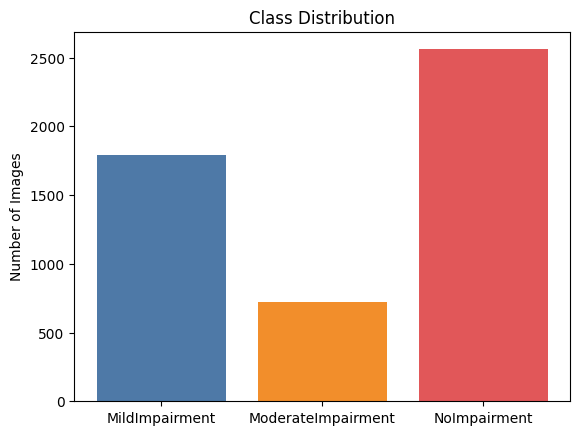

In [4]:
# Creates a bar chart of the distribution of data.
plt.bar(class_names, counts, color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title ('Class Distribution')
plt.ylabel ('Number of Images')
plt.show()

## Creating the datasets



In [5]:
# Create the training dataset (80%)
train_ds = keras.utils.image_dataset_from_directory(
    basepath,
    subset = "training",
    labels='inferred',
    validation_split=0.2,
    seed = 2614,
    batch_size = 32,
    shuffle = True
    )
# Creating the validation dataset (20%).
test_val_data = keras.utils.image_dataset_from_directory(basepath,
    labels='inferred',
    subset = "validation",
    validation_split=0.2,
    seed = 2614,
    batch_size = 32,
    shuffle = True)


Found 5076 files belonging to 3 classes.
Using 4061 files for training.
Found 5076 files belonging to 3 classes.
Using 1015 files for validation.


*keras.utils.image_dataset_from_directory* streams data in batches of 32, so the below code sets the first half of every batch as the validation dataset, and the last half of every batch as the test dataset

In [6]:
# Split val_data into validation and test datasets.
val_ds = test_val_data.take(16)
test_ds = test_val_data.skip(16)

In [6]:
# A CNN with one layer.
modelv1 = models.Sequential([
    Input(shape=(256, 256, 3)), # 256 x 256 pixel images in three colours
    Conv2D(filters=32, kernel_size=3, activation='relu'), # 32 feature maps at a time, looking in a 3x3 window.
    MaxPooling2D (2,2), # Selects 4 pixels and retains the highest signal, accelerates processing.
    Flatten(), # Turns it into a 1D array.
    Dropout(rate = 0.1), # Randomly turns off 10% of neurons: helps with overfitting.
    Dense(units = 3, activation = 'softmax') # Final classification is one of three classes.
])

In [7]:
# Adam is a stochastic gradient descent optimisation algorithm
modelv1.compile(optimizer = Adam(learning_rate = 0.003),
              loss = "sparse_categorical_crossentropy",
              metrics =['accuracy'])
modelv1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │     1,548,387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,549,283 (5.91 MB)

 Trainable params: 1,549,283 (5.91 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Stops training early if val_loss doesn't improve 4 epochs in a row, restores back to the best epoch.
early_stopping_callback = EarlyStopping(
    monitor = 'val_loss',
    patience = 4,
    restore_best_weights = True
)

In [9]:
# Trains the data on the training data set, while testing on the validation dataset in between epochs.
historyv1 = modelv1.fit(train_ds, validation_data = val_ds,
    batch_size=32,
    epochs=20, shuffle=True,
    callbacks = [early_stopping_callback])


Epoch 1/20


2026-02-01 15:39:33.552596: I external/local_xla/xla/service/service.cc:163] XLA service 0x774aa8008d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 15:39:33.552767: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-02-01 15:39:33.617246: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 15:39:33.801661: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-01 15:39:34.926661: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_490', 132 bytes spill stores, 132 bytes spill loads

2026-02-01 15:39:34.991928: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation

  5/127 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3165 - loss: 4599.2414

I0000 00:00:1769960380.025609   23768 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/127 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4112 - loss: 1551.1745

2026-02-01 15:39:45.890973: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_490', 132 bytes spill stores, 132 bytes spill loads

2026-02-01 15:39:45.927989: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_490', 132 bytes spill stores, 132 bytes spill loads

2026-02-01 15:39:46.099647: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_490', 12 bytes spill stores, 12 bytes spill loads



127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4122 - loss: 1533.7880

2026-02-01 15:39:50.407427: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 176 bytes spill stores, 176 bytes spill loads

2026-02-01 15:39:50.447860: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 132 bytes spill stores, 132 bytes spill loads

2026-02-01 15:39:50.500325: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_64', 12 bytes spill stores, 12 bytes spill loads



127/127 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.4708 - loss: 445.5327 - val_accuracy: 0.6211 - val_loss: 0.8402
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6119 - loss: 0.8487 - val_accuracy: 0.5820 - val_loss: 0.8685
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.6607 - loss: 0.7504 - val_accuracy: 0.6426 - val_loss: 0.8031
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7099 - loss: 0.6672 - val_accuracy: 0.6387 - val_loss: 0.7934
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7491 - loss: 0.5964 - val_accuracy: 0.6016 - val_loss: 0.9226
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.7742 - loss: 0.5348 - val_accuracy: 0.6602 - val_loss: 0.7858
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8220 - loss: 0.4598 - val_accuracy: 0.6621 - val_loss: 0.8154
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8269 - loss: 0.4430 - val_accuracy: 0.

## Plotting accuracy and loss graphs for modelv1.

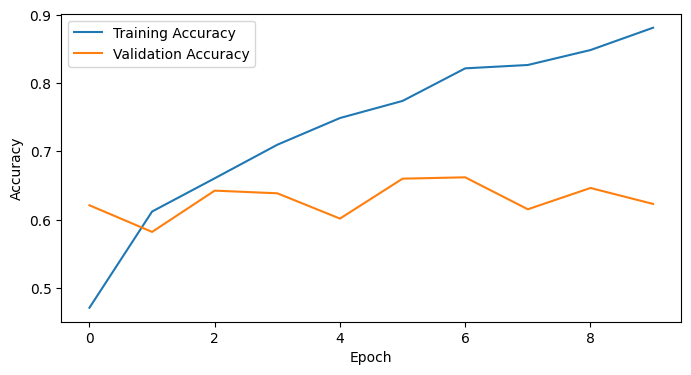

In [10]:
# Plots training vs validation accuracy

epochv1 = historyv1.epoch

accv1 = historyv1.history['accuracy']
valaccv1 = historyv1.history['val_accuracy']

plt.figure(figsize=(8,4))
plt.plot(epochv1, accv1, label = 'Training Accuracy')
plt.plot(epochv1, valaccv1, label = 'Validation Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

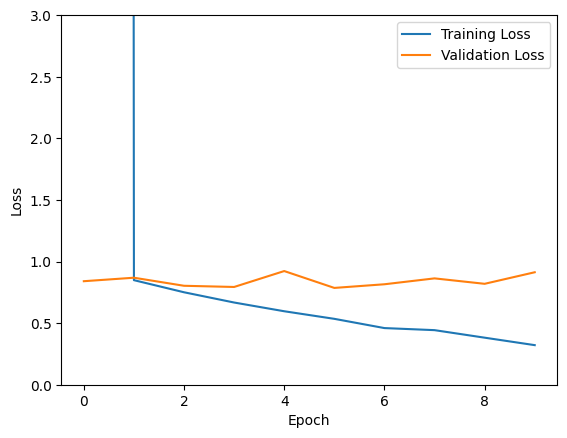

In [11]:
# Plots training vs validation loss
lossv1 = historyv1.history['loss']
vallossv1 = historyv1.history['val_loss']

plt.plot (epochv1, lossv1, label = 'Training Loss')
plt.plot (epochv1, vallossv1, label = 'Validation Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.ylim (0,3)
plt.legend(loc = 'upper right')
plt.show()

## Creating the classification report

In [12]:
# Returns the raw output from the test datatset going through the model.
y_prob = modelv1.predict(test_ds)
print(train_ds.class_names)
print(y_prob[0:10])
print(y_prob.shape)

11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

2026-02-01 15:40:55.740400: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 12 bytes spill stores, 12 bytes spill loads

2026-02-01 15:40:55.864403: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 132 bytes spill stores, 132 bytes spill loads

2026-02-01 15:40:55.902370: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 132 bytes spill stores, 132 bytes spill loads



16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
['MildImpairment', 'ModerateImpairment', 'NoImpairment']
[[0.51717997 0.05000216 0.4328178 ]
 [0.05514605 0.14403203 0.80082196]
 [0.35243088 0.05456315 0.593006  ]
 [0.22076797 0.02780975 0.7514223 ]
 [0.40290847 0.05584732 0.54124427]
 [0.8652317  0.12215717 0.01261116]
 [0.2264687  0.1939521  0.5795792 ]
 [0.24537423 0.01399139 0.7406344 ]
 [0.15508576 0.3291972  0.515717  ]
 [0.61860937 0.31857604 0.06281459]]
(503, 3)


In [13]:
# The index of the highest value is selected as a class label.
y_pred = np.argmax(y_prob, axis = 1)
print (y_pred)

[0 2 2 2 2 0 2 2 2 0 2 2 2 2 1 0 0 2 2 0 2 1 0 2 0 0 2 1 0 0 0 2 2 0 0 0 0
 0 1 0 0 2 2 0 1 2 0 0 0 2 2 0 2 0 2 2 1 1 2 2 0 0 1 2 2 2 2 2 2 1 1 2 0 0
 1 0 0 2 0 2 2 0 2 0 2 2 0 2 1 2 0 0 2 2 0 0 0 2 0 0 2 0 2 0 2 0 2 2 1 0 2
 0 0 0 2 0 0 2 0 0 0 1 2 0 0 0 2 1 0 0 0 0 1 2 2 0 0 2 2 2 1 2 1 2 2 0 2 2
 2 2 0 0 0 1 2 0 2 2 0 1 2 2 0 0 1 2 0 0 0 0 2 0 0 0 0 0 2 0 1 1 1 2 0 2 2
 2 0 0 2 0 2 2 1 2 0 2 2 2 2 0 2 0 0 2 1 2 2 2 2 0 0 2 2 2 2 0 0 2 0 0 2 2
 2 0 0 2 2 2 2 2 2 2 2 2 0 2 2 0 0 0 2 0 2 0 1 0 2 2 0 0 0 2 1 2 2 0 2 2 0
 2 2 0 0 2 0 0 2 2 2 0 2 0 0 2 2 0 0 2 1 2 2 0 2 0 0 0 2 0 2 0 1 1 2 2 0 0
 0 0 0 1 1 1 2 2 0 1 2 2 1 0 2 1 2 2 2 1 0 1 2 2 2 2 2 0 0 0 2 0 2 2 2 2 2
 2 2 0 2 0 2 2 2 2 0 2 0 0 2 0 0 2 2 1 2 2 0 1 2 2 2 2 2 1 0 2 0 2 0 2 0 2
 2 0 2 0 1 2 2 2 2 2 0 0 0 0 0 2 0 0 0 2 0 2 0 2 0 0 0 0 1 0 0 2 2 0 0 0 0
 2 2 0 2 2 2 2 2 0 2 2 2 0 2 0 2 2 1 2 1 2 2 2 2 2 2 2 0 0 0 2 0 2 2 2 0 0
 2 2 0 0 2 2 2 0 0 2 2 0 0 0 0 2 0 2 1 1 2 2 2 0 2 2 2 0 0 2 0 0 1 2 2 2 0
 2 2 2 0 2 0 2 2 0 2 2 2 

In [14]:
# Get the true labels from the test set
y_true = []
for images, labels in test_ds: # Loops throught the test set and aggregates the true labels in each batch into a single list.
    y_true.extend(labels.numpy())

y_true = np.array(y_true) # Turns y_true into a numpy array.
print("True Labels Shape:", y_true.shape)
print("Predicted Labels Shape:", y_pred.shape)

True Labels Shape: (503,)
Predicted Labels Shape: (503,)


2026-02-01 15:41:02.724170: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
# Print the metrics table
print(classification_report(y_true, y_pred, target_names = class_names))
modelv1.evaluate(test_ds)

                    precision    recall  f1-score   support

    MildImpairment       0.34      0.40      0.37       170
ModerateImpairment       0.12      0.09      0.10        67
      NoImpairment       0.47      0.45      0.46       266

          accuracy                           0.38       503
         macro avg       0.31      0.31      0.31       503
      weighted avg       0.38      0.38      0.38       503

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6581 - loss: 0.7931


[0.7930617928504944, 0.6580516695976257]

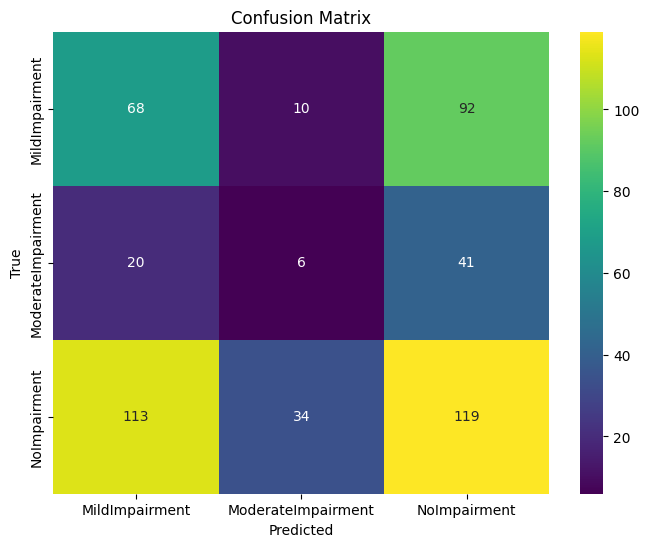

In [16]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

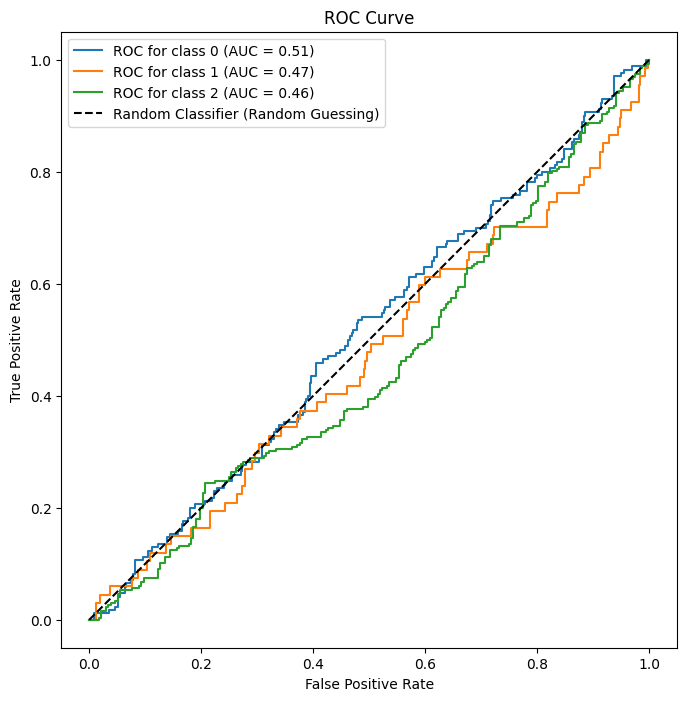

In [17]:
# Creates a ROC curve.
fig, ax = plt.subplots(figsize=(8,8))

# Loops through each class and generates a "One-vs-Rest" curve for each.
for class_id in range(3):
    binary_labels = (y_true == class_id) # Binarize the labels.
    class_probabilities = y_prob[:, class_id] # Select the probability column corresponding to the current class.
    RocCurveDisplay.from_predictions( # Plot ROC curve
        binary_labels,
        class_probabilities,
        name=f"ROC for class {class_id}",
        ax=ax
    )

plt.plot([0,1], [0,1], "k--", label = "Random Classifier (Random Guessing)") # Plots the diagonal line representing the random classifier.
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Second iteration of the model
#### The first model shows evidence of severe overfitting, so we do three things to address it:
- Data Augmentation
- Add multiple layers to the CNN
- Tune the learning rate

In [18]:
# This model randomly flips, rotates and zooms each image to prevent overfitting during training.
# Goes through 3 convolution layers, with filter doubling each time to learn more complex features.
modelv2 = models.Sequential([
    Input(shape=(256, 256, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.Rescaling(scale=1./255), # Normalises pixel values from [0,255] to [0,1].
    Conv2D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Conv2D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Conv2D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling2D (2,2),
    Flatten(),
    Dropout(rate = 0.1),
    Dense(units = 3, activation = 'softmax')
])

In [19]:
modelv2.compile(optimizer = Adam(learning_rate = 0.001),
              loss = "sparse_categorical_crossentropy",
              metrics =['accuracy'])
modelv2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │       345,603 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,851 (1.67 MB)

 Trainable params: 438,851 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
historyv2 = modelv2.fit(train_ds, validation_data = val_ds,
batch_size=32,
epochs=50, shuffle=True,
callbacks = [early_stopping_callback])

Epoch 1/50


2026-02-01 15:41:45.041522: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 832.39MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.4910 - loss: 1.0110 - val_accuracy: 0.5449 - val_loss: 0.9762
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.5314 - loss: 0.9362 - val_accuracy: 0.5938 - val_loss: 0.8516
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.5501 - loss: 0.9028 - val_accuracy: 0.5645 - val_loss: 0.8557
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.5573 - loss: 0.8871 - val_accuracy: 0.5801 - val_loss: 0.8653


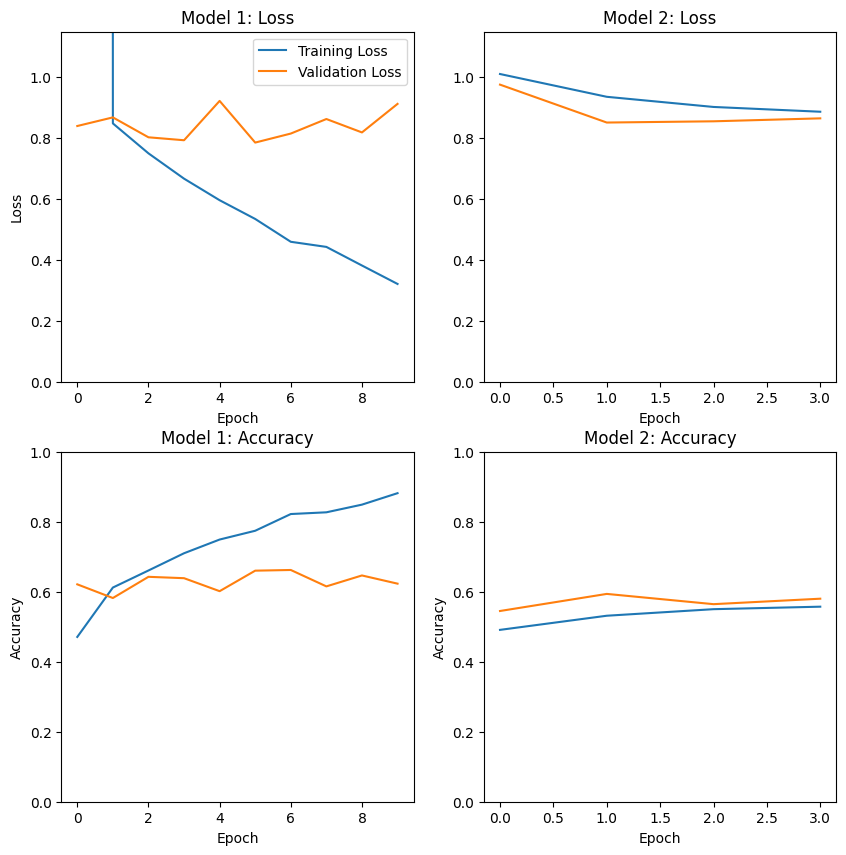

In [21]:
# Comparison graphs of the accuracy and loss between the first and second models.
epochv2 = historyv2.epoch
lossv2 = historyv2.history['loss']
vallossv2 = historyv2.history['val_loss']
accv2 = historyv2.history['accuracy']
valaccv2 = historyv2.history['val_accuracy']

fig, ([ax1, ax2], [ax3, ax4]) = plt.subplots(2,2, figsize=(10,10))

ax1.plot (epochv1, lossv1, label = 'Training Loss')
ax1.plot (epochv1, vallossv1, label = 'Validation Loss')
ax1.set_title("Model 1: Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylim(0,1.15)
ax1.legend()

ax2.plot (epochv2, lossv2, label = 'Training Loss')
ax2.plot (epochv2, vallossv2, label = 'Validation Loss')
ax2.set_title("Model 2: Loss")
ax2.set_ylim(0,1.15)
ax2.set_xlabel("Epoch")

ax3.plot(epochv1, accv1, label = 'Training Accuracy')
ax3.plot(epochv1, valaccv1, label = 'Validation Accuracy')
ax3.set_ylabel("Accuracy")
ax3.set_xlabel("Epoch")
ax3.set_ylim(0,1)
ax3.set_title("Model 1: Accuracy")

ax4.plot(epochv2, accv2, label = 'Training Accuracy')
ax4.plot(epochv2, valaccv2, label = 'Validation Accuracy')
ax4.set_ylabel("Accuracy")
ax4.set_xlabel("Epoch")
ax4.set_ylim(0,1)
ax4.set_title("Model 2: Accuracy")

plt.show()

In [22]:
y_probv2 = modelv2.predict(test_ds)
print(train_ds.class_names)
print(y_probv2[0:10])
print(y_probv2.shape)

y_predv2 = np.argmax(y_probv2, axis = 1)
print (y_predv2)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
['MildImpairment', 'ModerateImpairment', 'NoImpairment']
[[0.31460994 0.21185671 0.47353327]
 [0.24172795 0.15822875 0.6000433 ]
 [0.22842905 0.14954317 0.62202775]
 [0.3339765  0.2366789  0.42934456]
 [0.2984147  0.21943502 0.48215023]
 [0.306197   0.24911273 0.44469023]
 [0.290986   0.21874943 0.49026462]
 [0.30467123 0.22126314 0.4740656 ]
 [0.3587268  0.29356945 0.34770375]
 [0.36769614 0.31846446 0.31383935]]
(503, 3)
[2 2 2 2 2 2 2 2 0 0 2 2 2 2 0 2 2 2 2 0 2 2 2 2 0 2 0 1 2 2 2 2 0 0 2 0 2
 2 2 2 2 0 1 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 2 2 2 1 2 0 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 0 0 0 2 2 2 0 2 0 2 0 2 2 0 2 0 2 2 0 2
 0 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 0 2 0 2 0 0 2 0 2 2 2 2 0 2 0 2
 2 2 2 2 2 0 2 1 2 0 2 0 2 0 2 2 2 1 2 1 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0 2 2 0 2 0 2 2 0 2 2 0 2 2 2 2 0 2 2 2 2 0 0 2 0 2 2 2 2 1 2 0 2 1 2 1
 2 0 0 1 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 0 2 2 0 2 1 0 0 2 2 2 2 2 2 0 2 2
 2 0 2 2

In [23]:
y_truev2 = []
for images, labels in test_ds:
    y_truev2.extend(labels.numpy())

y_truev2 = np.array(y_truev2)
print("True Labels Shape:", y_truev2.shape)
print("Predicted Labels Shape:", y_predv2.shape)

True Labels Shape: (503,)
Predicted Labels Shape: (503,)


2026-02-01 15:44:05.932020: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [24]:
print(classification_report(y_truev2, y_predv2, target_names=class_names))

                    precision    recall  f1-score   support

    MildImpairment       0.34      0.23      0.28       182
ModerateImpairment       0.11      0.05      0.06        66
      NoImpairment       0.51      0.71      0.59       255

          accuracy                           0.45       503
         macro avg       0.32      0.33      0.31       503
      weighted avg       0.40      0.45      0.41       503



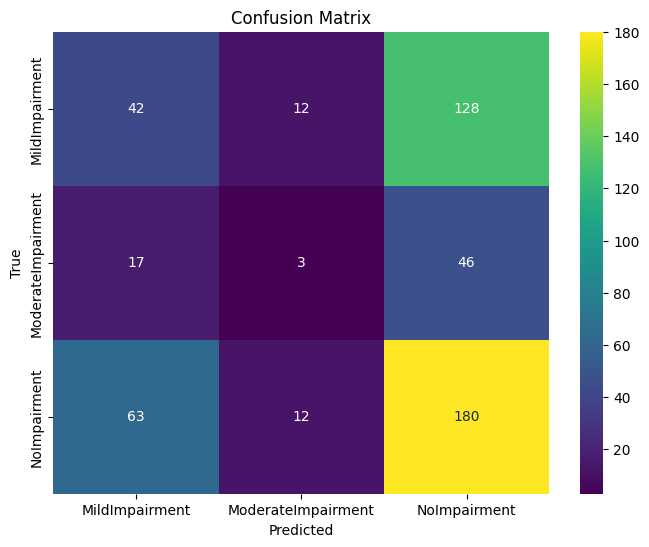

In [25]:
# Create the confusion matrix
cm = confusion_matrix(y_truev2, y_predv2)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Third iteration of model: Using ResNet

In [26]:
# Loads ResNet, a prebuilt classification model.
resnet_model = keras.applications.ResNet50(
    include_top=False,  # Removes the final classification layer
    weights="imagenet", # Uses the weights tuned from pre-trained images.
    input_shape=(256, 256, 3),
    pooling='avg',  # Turn the 3D output into 1D vector, replaces Flatten()
)

# Freezes the weighting, preventing them from being changed during training.
resnet_model.trainable = False

print(f"Total layers: {len(resnet_model.layers)}")
print(f"Total weights: {len(resnet_model.weights)}")
print(f"Total Trainable Weights: {len(resnet_model.trainable_weights)}")
print(f"Total Non-Trainable Weights: {len(resnet_model.non_trainable_weights)}")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Total layers: 176
Total weights: 318
Total Trainable Weights: 0
Total Non-Trainable Weights: 318


In [ ]:
modelv3 = models.Sequential([
    resnet_model,
    Dense(256, activation = 'relu'), # Compresses the 2048 general features into 256 features specific to images.
    Dropout(rate = 0.1),
    Dense(3, activation = 'softmax')
    ])

modelv3.compile(optimizer='Adam',
              loss = "sparse_categorical_crossentropy",
              metrics =['accuracy'])
modelv3.summary()

class_weight_dict = ({
    0 : 1.022,
    1 : 2.306,
    2 : 0.630
})


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [87]:
historyv3 = modelv3.fit(train_ds, validation_data = val_ds,
batch_size=32,
epochs=50, shuffle=True,
class_weight = class_weight_dict,
callbacks = [early_stopping_callback])

Epoch 1/50


2026-02-01 17:51:51.966406: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


127/127 ━━━━━━━━━━━━━━━━━━━━ 33s 198ms/step - accuracy: 0.4782 - loss: 1.1113 - val_accuracy: 0.5527 - val_loss: 0.9309
Epoch 2/50
  1/127 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.6562 - loss: 0.9570

2026-02-01 17:52:20.970624: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.5270 - loss: 0.9532

...

127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.5614 - loss: 0.8774 - val_accuracy: 0.6230 - val_loss: 0.7664
Epoch 4/50
  1/127 ━━━━━━━━━━━━━━━━━━━━ 17s 143ms/step - accuracy: 0.5938 - loss: 0.9267

2026-02-01 17:52:54.749986: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5793 - loss: 0.8681

2026-02-01 17:53:09.733485: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


127/127 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.5895 - loss: 0.8343 - val_accuracy: 0.5391 - val_loss: 0.9492


In [88]:
# Provides the loss and accuracy on the test dataset.
resnetloss, resnetaccuracy = modelv3.evaluate(test_ds)
print(f"Accuracy: {resnetaccuracy}\nLoss: {resnetloss}")

2026-02-01 17:59:31.364619: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 258ms/step - accuracy: 0.5129 - loss: 0.9370
Accuracy: 0.512922465801239
Loss: 0.9370425343513489


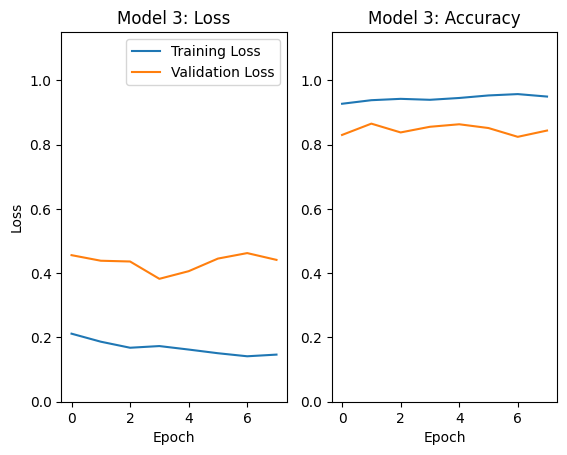

In [74]:
# Produces loss and accuracy graphs.
epochv3 = historyv3.epoch
lossv3 = historyv3.history['loss']
vallossv3 = historyv3.history['val_loss']
accv3 = historyv3.history['accuracy']
valaccv3 = historyv3.history ['val_accuracy']


fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot (epochv3, lossv3, label = 'Training Loss')
ax1.plot (epochv3, vallossv3, label = 'Validation Loss')
ax1.set_title("Model 3: Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylim(0,1.15)
ax1.legend()

ax2.plot (epochv3, accv3, label = 'Training Accuracy')
ax2.plot (epochv3, valaccv3, label = 'Validation Training Accuracy')
ax2.set_title("Model 3: Accuracy")
ax2.set_ylim(0,1.15)
ax2.set_xlabel("Epoch")

plt.show()

2026-02-01 17:44:58.190713: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


                    precision    recall  f1-score   support

    MildImpairment       0.76      0.91      0.83       166
ModerateImpairment       0.88      0.74      0.80        69
      NoImpairment       0.93      0.86      0.89       277

          accuracy                           0.86       512
         macro avg       0.86      0.84      0.84       512
      weighted avg       0.87      0.86      0.86       512



2026-02-01 17:45:02.582316: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


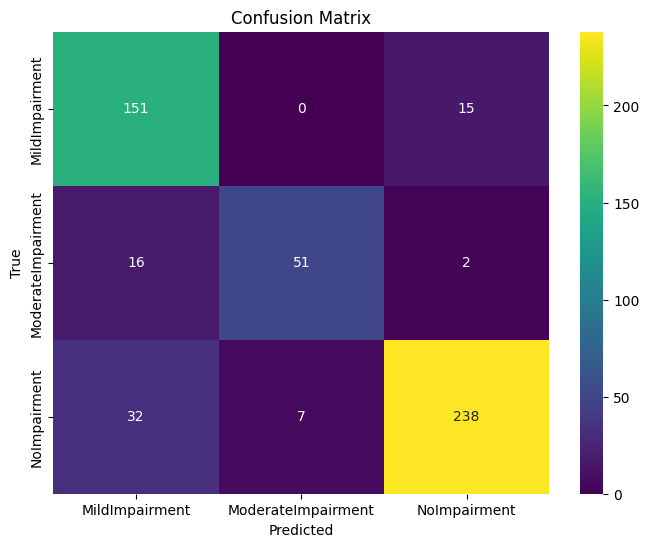

In [75]:
# Intialises the true and predicted lists.
y_truev3 = []
y_predv3 = []

# Loops through the validation dataset.
for images, labels in val_ds:
    # Gets the labels, converts them into numpy form, and adds it to y_truev3.
    y_truev3.extend(labels.numpy())

    # Get the prediction for this specific batch
    batch_preds = modelv3.predict(images, verbose=0)
    # Selects the highest value in the array and sets its index as the value.
    batch_labels = np.argmax(batch_preds, axis=1)
    # Adds the selected index to y_predv3.
    y_predv3.extend(batch_labels)

# Prints the classification report
print(classification_report(y_truev3, y_predv3, target_names = class_names))

# Create the confusion matrix
cm = confusion_matrix(y_truev3, y_predv3)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



# Fine Tuning the ResNet Model

In [8]:
resnet_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3),
    pooling='avg', 
)

# Initialises all the training weights
resnet_model.trainable = False

# # The last 5 layers are set to be re-trained against our dataset.
# # Bin normalisation layer must remain the same or performance suffers.
# for layer in resnet_model.layers[:-5]:
#     layer.trainable = False

# for layer in resnet_model.layers[-5:]:
#     if "bn" in layer.name:
#         layer.trainable = False
    
print(f"Total layers: {len(resnet_model.layers)}")
print(f"Total weights: {len(resnet_model.weights)}")
print(f"Total Trainable Weights: {len(resnet_model.trainable_weights)}")
print(f"Total Non-Trainable Weights: {len(resnet_model.non_trainable_weights)}")

# Check which layers are still allowed to learn
for layer in resnet_model.layers:
    if layer.trainable:
        print(f"Trainable: {layer.name}")

Total layers: 176
Total weights: 318
Total Trainable Weights: 0
Total Non-Trainable Weights: 318


In [12]:
modelv4 = models.Sequential([
    resnet_model,
    Dense(256, activation = 'relu'),
    Dropout(rate = 0.1),
    Dense(3, activation = 'softmax')
    ])

modelv4.compile(
    optimizer = Adam(learning_rate = 1e-5),
    loss = "sparse_categorical_crossentropy",
    metrics =['accuracy'])
modelv4.summary()

class_weight_dict = ({
    0 : 1.022,
    1 : 2.306,
    2 : 0.630
})
print(class_weight_dict)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

{0: 1.022, 1: 2.306, 2: 0.63}


In [13]:
historyv4 = modelv4.fit(
    train_ds,
    validation_data = val_ds,
    batch_size=32,
    epochs=50,
    shuffle=True,
    callbacks = [early_stopping_callback])

Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4341 - loss: 1.1241 - val_accuracy: 0.5059 - val_loss: 0.9947
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.4829 - loss: 1.0052 - val_accuracy: 0.5449 - val_loss: 0.9270
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.5110 - loss: 0.9605 - val_accuracy: 0.5273 - val_loss: 0.9020
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5302 - loss: 0.9278 - val_accuracy: 0.5508 - val_loss: 0.8767
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5430 - loss: 0.9157 - val_accuracy: 0.5742 - val_loss: 0.8686
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5592 - loss: 0.8960 - val_accuracy: 0.5625 - val_loss: 0.8743
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5715 - loss: 0.8771 - val_accuracy: 0.5527 - val_loss: 0.8693
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.5797 - loss: 0.8631 - val_accu

KeyboardInterrupt: 

In [11]:
# Provides the loss and accuracy on the test dataset.
ftresnetloss, ftresnetaccuracy = modelv4.evaluate(test_ds)
print(f"Accuracy: {ftresnetaccuracy}\nLoss: {ftresnetloss}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 838ms/step - accuracy: 0.5328 - loss: 0.9351
Accuracy: 0.5328031778335571
Loss: 0.9350797533988953


In [38]:
# Print the names of the layers that are currently set to train
for layer in resnet_model.layers:
    if layer.trainable:
        print(layer.name)

conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out
avg_pool


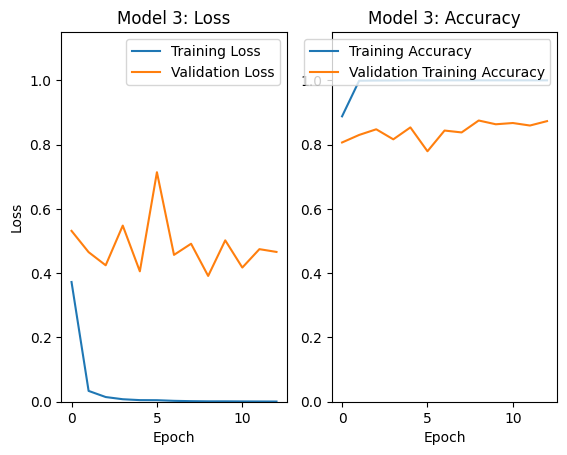

In [ ]:
# Produces loss and accuracy graphs.
epochv4 = historyv4.epoch
lossv4, vallossv4, accv4, valaccv4 = (historyv4.history['loss'], 
                                      historyv4.history['val_loss'], 
                                      historyv4.history['accuracy'], 
                                      historyv4.history['val_accuracy'])


fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot (epochv4, lossv4, label = 'Training Loss')
ax1.plot (epochv4, vallossv4, label = 'Validation Loss')
ax1.set_title("Model 4: Loss")
ax1.set_ylabel("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylim(0,1.15)
ax1.legend()

ax2.plot (epochv4, accv4, label = 'Training Accuracy')
ax2.plot (epochv4, valaccv4, label = 'Validation Training Accuracy')
ax2.set_title("Model 4: Accuracy")
ax2.set_ylim(0,1.15)
ax2.set_xlabel("Epoch")

plt.show()

Test Accuracy: 0.8608
Test Loss: 0.4498
                    precision    recall  f1-score   support

    MildImpairment       0.86      0.77      0.81       166
ModerateImpairment       0.75      0.86      0.80        81
      NoImpairment       0.89      0.91      0.90       265

          accuracy                           0.86       512
         macro avg       0.83      0.85      0.84       512
      weighted avg       0.86      0.86      0.85       512



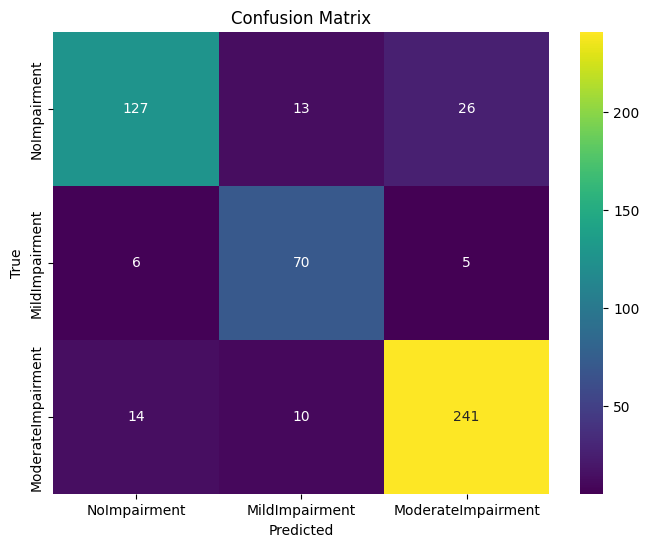

In [ ]:
y_truev4 = []
y_predv4 = []

for images, labels in val_ds:
    # Gets the labels
    y_truev4.extend(labels.numpy())

    # Get the prediction for this specific batch
    batch_preds = modelv4.predict(images, verbose=0)
    batch_labels = np.argmax(batch_preds, axis=1)
    y_predv4.extend(batch_labels)

# Print classification report.
print(classification_report(y_truev4, y_predv4, target_names=class_names))

# Create the confusion matrix
cm = confusion_matrix(y_truev4, y_pred)

# Plot it using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
